# End-to-End Customer Segmentation, Churn Prediction & Retention Analytics using Machine Learning

 Project Scenario

"Customer churn has increased over the past few months. We have customer data, but we don't know who is likely to leave. Build a machine learning solution that predicts churn so our marketing team can contact at-risk customers before they leave."Develop a machine learning model that predicts customer churn using historical customer data and provides business recommendations to improve customer retention.

In [1]:
%pip install pandas, numpy matplotlib seaborn scikit-learn xgboost shap streamlit imbalanced-learn joblib

Note: you may need to restart the kernel to use updated packages.


ERROR: Invalid requirement: 'pandas,'

[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Data Collection

import libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Ignore warning messages
import warnings
warnings.filterwarnings("ignore")

# Display plots inside Jupyter Notebook
%matplotlib inline

In [4]:
#LOAD THE DATA SET
df = pd.read_csv("dataset/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Display First Five Rows

df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
# Display Dataset Shape
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 7043
Columns: 21


In [6]:
# Step 2: Display Last 5 Rows
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [7]:
#DISPPLAY THE COLUM NAMES
print(df.columns)

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


# DATA UNDERSTANDING

In [8]:
#display colum names
df.columns


Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [9]:
#check dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [10]:
#Statistical Summary (to get mean, median, std,count)
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [11]:
#Categorical Summary
df.describe(include="object")

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [12]:
#missing values
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [13]:
# Check blank values in TotalCharges
(df["TotalCharges"] == " ").sum()

np.int64(11)

In [14]:
#Check Duplicate Records
df.duplicated()


0       False
1       False
2       False
3       False
4       False
        ...  
7038    False
7039    False
7040    False
7041    False
7042    False
Length: 7043, dtype: bool

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
#Check Unique Values in Each Column
df.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

In [17]:
print(df.shape)

(7043, 21)


In [18]:
#Target Variable Distribution
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [19]:
(df["Churn"].value_counts(normalize=True) * 100).round(2)

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

5,174 customers stayed with the company (No).
1,869 customers left the company (Yes).

Out of every 100 customers:

About 73 customers stayed.
About 27 customers left.

# Data Cleaning

In [20]:
 #Check Blank Values
(df["TotalCharges"] == " ").sum()

np.int64(11)

In [21]:
#Replace Blank Values with NaN

df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)

In [22]:
#chechking blank spaces are exit
(df["TotalCharges"] == " ").sum()

np.int64(0)

In [23]:
#Convert Data Type into numeric the total charges colum

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

In [24]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [25]:
#(removig the missing values because Removing them has almost no effect on the dataset.It avoids introducing artificial values. )
#Remove Missing Values 
df.dropna(inplace=True)
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [26]:
df.duplicated().sum()

np.int64(0)

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

In [28]:
print(df.shape)    #orginally there is 7043 rows there we remove 11 misig values from data now it is 7032

(7032, 21)


# Exploratory Data Analysis (EDA)

In [29]:
#  Identify Numerical and Categorical Columns

numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns
categorical_columns = df.select_dtypes(include=['object']).columns


print("Numerical Columns:")
print(numerical_columns)

print("\nCategorical Columns:")
print(categorical_columns)

Numerical Columns:
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')

Categorical Columns:
Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')


Observation: The majority of customers are not senior citizens (0), while a smaller proportion are senior citizens (1).

1.  Churn Distribution

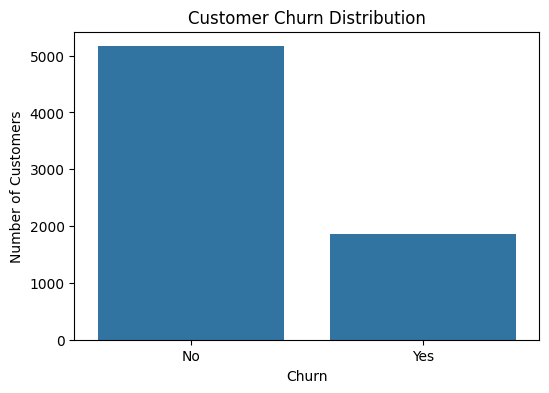

In [30]:
#Churn Distribution

plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

Observation:

Most customers did not churn.
Around 73.46% of customers stayed with the company.
Around 26.54% of customers churned.
The dataset is moderately imbalanced because the number of customers who stayed is much higher than those who churned.

2. Contract Type vs Churn

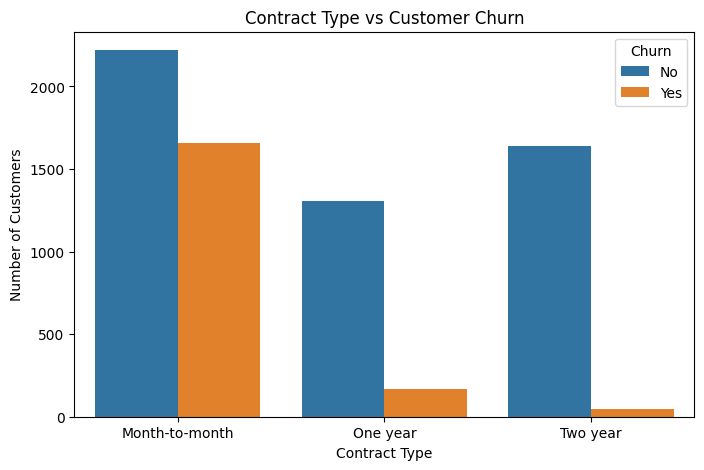

In [31]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="Contract", hue="Churn")

plt.title("Contract Type vs Customer Churn")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.show()

Observation:

Customers with Month-to-month contracts have the highest churn.
Customers with One-year and Two-year contracts have much lower churn.
Longer-term contracts appear to improve customer retention.

Customers on month-to-month contracts are more likely to leave because they are not committed for a long period. Encouraging these customers to switch to annual or two-year contracts could help reduce churn.

3. Internet Service vs Churn

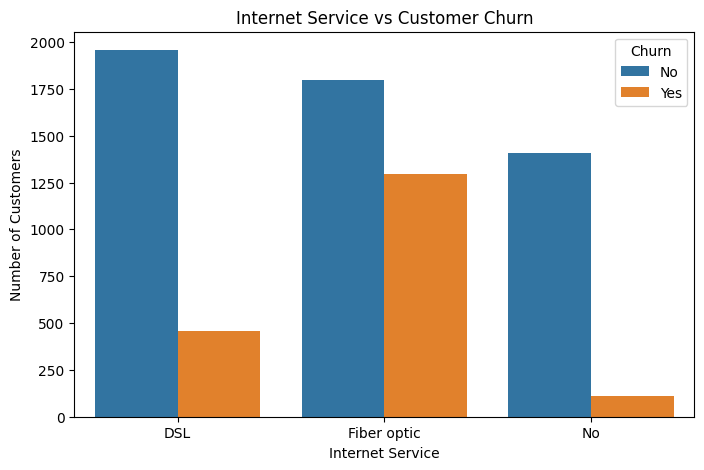

In [32]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="InternetService", hue="Churn")

plt.title("Internet Service vs Customer Churn")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.show()

Observation

From the graph, we can observe:

Fiber optic customers have the highest number of churned customers.
DSL customers have a much lower number of churned customers.
Customers with No Internet Service have the lowest churn.
Although many Fiber optic customers stay, the number of customers leaving is much higher than in the other internet service categories.

4. Tech Support vs Churn

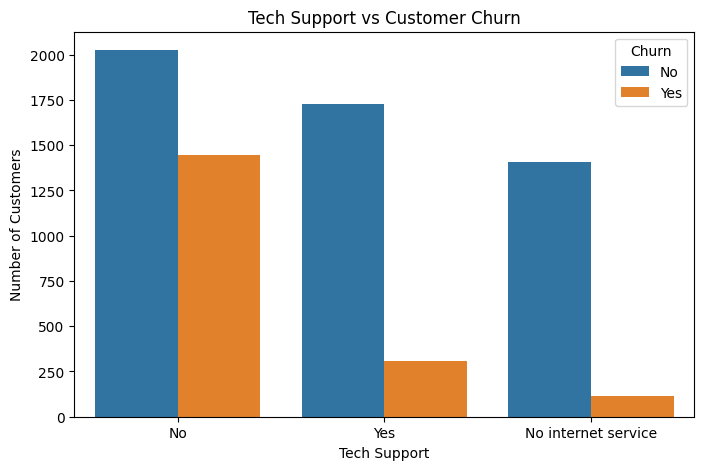

In [33]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="TechSupport", hue="Churn")

plt.title("Tech Support vs Customer Churn")
plt.xlabel("Tech Support")
plt.ylabel("Number of Customers")

plt.show()

Observation

From the graph, we can observe:

Customers without Tech Support ("No") have the highest number of churned customers.
Customers with Tech Support ("Yes") have much lower churn.
Customers with No Internet Service also have very low churn, but they don't use internet-based services, so tech support is less relevant for them.

5. Monthly Charges Distribution

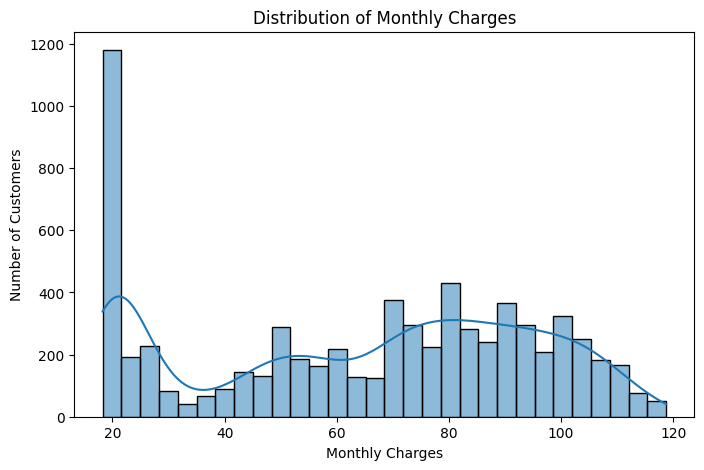

In [34]:
plt.figure(figsize=(8,5))

sns.histplot(df["MonthlyCharges"], bins=30, kde=True)

plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")

plt.show()

Observation

From the graph, we can observe:

Monthly charges range from approximately ₹18 to ₹120.
A large number of customers pay around ₹20 per month.
Another large group of customers pays between ₹70 and ₹100 per month.
The distribution is not normally distributed. It has multiple peaks (multimodal) instead of one single peak.

6. Tenure Distribution

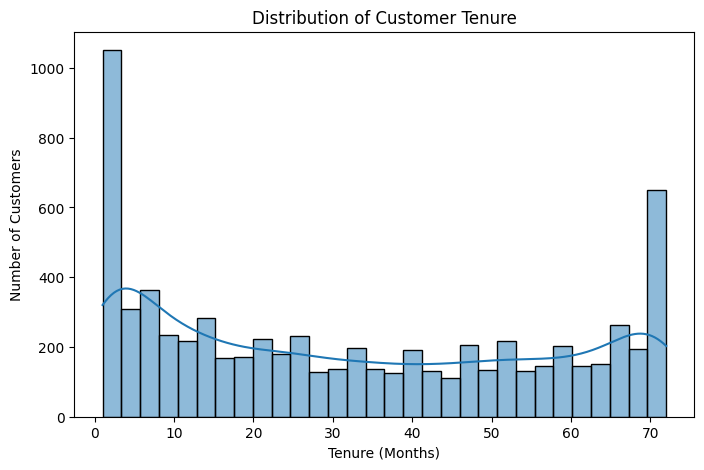

In [35]:
plt.figure(figsize=(8,5))

sns.histplot(df["tenure"], bins=30, kde=True)

plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

Observation

From the graph, we can observe:

Customer tenure ranges from 1 month to 72 months.
A large number of customers have a very short tenure (1–5 months).
Another large group of customers has a very long tenure (around 70–72 months).
There are fewer customers in the middle tenure range.
The distribution is bimodal (two peaks), not normally distributed.

7. Monthly Charges vs Churn

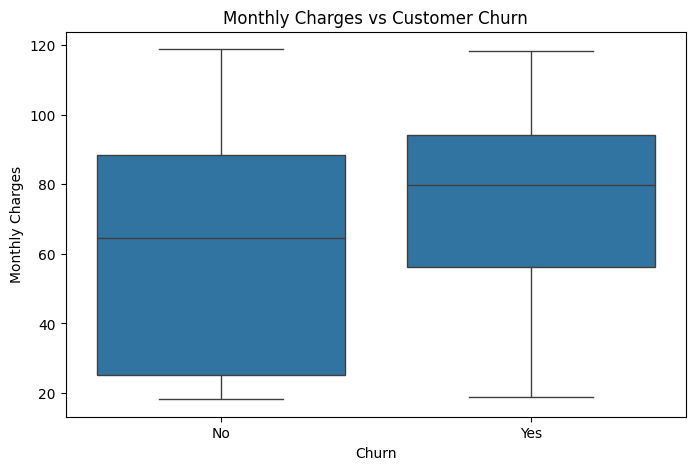

In [36]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="Churn", y="MonthlyCharges")

plt.title("Monthly Charges vs Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()


Observation

From your graph, we can observe:

Customers who did not churn (No) have a median monthly charge of approximately ₹64.
Customers who churned (Yes) have a higher median monthly charge of approximately ₹80.
The monthly charges for churned customers are generally higher than those of customers who stayed.
Both groups have similar minimum and maximum values, but the overall distribution for churned customers is shifted toward higher charges.

8.  Tenure vs Churn

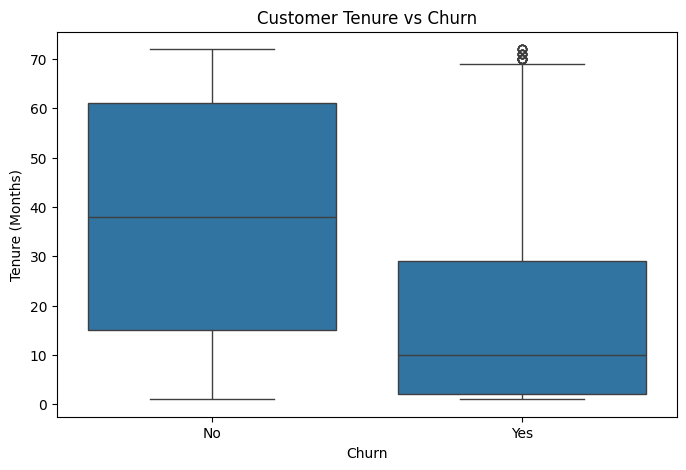

In [37]:

plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="Churn", y="tenure")

plt.title("Customer Tenure vs Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

Observation

From your graph, we can observe:

Customers who did not churn (No) have a much higher median tenure (around 38 months).
Customers who churned (Yes) have a much lower median tenure (around 10 months).
Most churned customers have been with the company for only a short period.
Most long-term customers remain with the company.
A few churned customers with very high tenure (around 70–72 months) appear as outliers.

8. Correlation Heatmap

<Axes: >

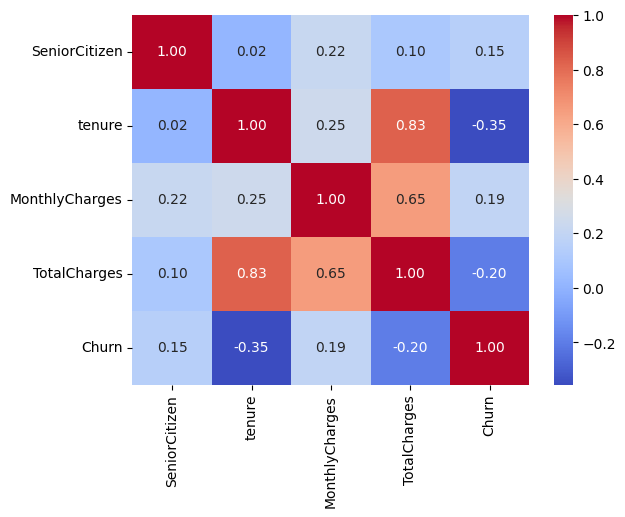

In [38]:
heatmap_df = df[
    [
        "SeniorCitizen",
        "tenure",
        "MonthlyCharges",
        "TotalCharges",
        "Churn"
    ]
].copy()

heatmap_df["Churn"] = heatmap_df["Churn"].map(
    {"No": 0, "Yes": 1}
)

sns.heatmap(
    heatmap_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

Observation of the Correlation Heatmap
Tenure and TotalCharges have a strong positive correlation (0.83). This means customers who stay with the company for a longer time tend to have higher total charges because they continue paying for the service over many months.
MonthlyCharges and TotalCharges have a moderate positive correlation (0.65). Customers with higher monthly bills generally accumulate higher total charges over time.
Tenure and MonthlyCharges have a weak positive correlation (0.25). This indicates that the length of time a customer stays with the company has only a small relationship with their monthly bill.

SeniorCitizen has very weak correlations with the other numerical features:

SeniorCitizen ↔ Tenure = 0.02
SeniorCitizen ↔ MonthlyCharges = 0.22
SeniorCitizen ↔ TotalCharges = 0.10

This suggests that being a senior citizen has little influence on these numerical variables.

# Customer segmentation

Select features for customer segmentation

In [39]:
# Step 1: Select Features for Customer Segmentation

segmentation_features = df[
    ["tenure", "MonthlyCharges", "TotalCharges"]
].copy()

print("Shape of segmentation data:", segmentation_features.shape)

segmentation_features.head()

Shape of segmentation data: (7032, 3)


,tenure,MonthlyCharges,TotalCharges
0,1,29.85,29.85
1,34,56.95,1889.50
2,2,53.85,108.15
3,45,42.30,1840.75
4,2,70.70,151.65


Check missing values and data types

In [40]:
# Step 2: Check segmentation features

print("Missing Values:")
print(segmentation_features.isnull().sum())

print("\nData Types:")
print(segmentation_features.dtypes)

print("\nBasic Statistics:")
print(segmentation_features.describe())

Missing Values:
tenure            0
MonthlyCharges    0
TotalCharges      0
dtype: int64

Data Types:
tenure              int64
MonthlyCharges    float64
TotalCharges      float64
dtype: object

Basic Statistics:
            tenure  MonthlyCharges  TotalCharges
count  7032.000000     7032.000000   7032.000000
mean     32.421786       64.798208   2283.300441
std      24.545260       30.085974   2266.771362
min       1.000000       18.250000     18.800000
25%       9.000000       35.587500    401.450000
50%      29.000000       70.350000   1397.475000
75%      55.000000       89.862500   3794.737500
max      72.000000      118.750000   8684.800000


Feature Scaling

In [41]:
# Step 3: Feature Scaling for Customer Segmentation

from sklearn.preprocessing import StandardScaler

scaler_seg = StandardScaler()

segmentation_scaled = scaler_seg.fit_transform(
    segmentation_features
)

print("Shape after scaling:", segmentation_scaled.shape)

print("\nFirst 5 scaled rows:")
print(segmentation_scaled[:5])

Shape after scaling: (7032, 3)

First 5 scaled rows:
[[-1.28024804 -1.16169394 -0.99419409]
 [ 0.06430269 -0.26087792 -0.17373982]
 [-1.23950408 -0.36392329 -0.95964911]
 [ 0.51248626 -0.74785042 -0.19524771]
 [-1.23950408  0.19617818 -0.94045745]]


Elbow Method

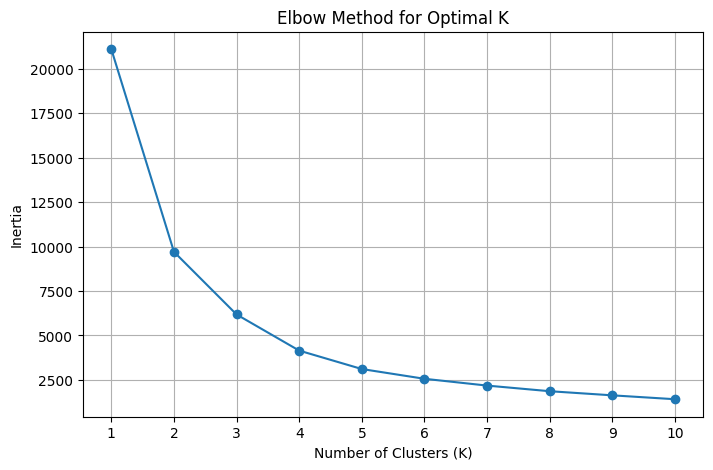

K = 1: Inertia = 21096.00
K = 2: Inertia = 9700.83
K = 3: Inertia = 6176.72
K = 4: Inertia = 4144.59
K = 5: Inertia = 3108.41
K = 6: Inertia = 2559.84
K = 7: Inertia = 2177.75
K = 8: Inertia = 1861.12
K = 9: Inertia = 1629.20
K = 10: Inertia = 1410.83


In [42]:
# Step 4: Elbow Method to find suitable number of clusters

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(segmentation_scaled)
    inertia.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(8, 5))

plt.plot(K_range, inertia, marker='o')

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")

plt.xticks(K_range)
plt.grid()

plt.show()

# Print inertia values
for k, value in zip(K_range, inertia):
    print(f"K = {k}: Inertia = {value:.2f}")

In [43]:
# Step 5: Calculate Silhouette Score

from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

silhouette_scores = {}

for k in range(2, 7):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    cluster_labels = kmeans.fit_predict(segmentation_scaled)

    score = silhouette_score(
        segmentation_scaled,
        cluster_labels
    )

    silhouette_scores[k] = score

    print(f"K = {k}: Silhouette Score = {score:.4f}")

K = 2: Silhouette Score = 0.4795
K = 3: Silhouette Score = 0.4515
K = 4: Silhouette Score = 0.4721
K = 5: Silhouette Score = 0.4433
K = 6: Silhouette Score = 0.4376


In [44]:
# Step 6: Compare K=2 and K=4 cluster profiles

for k in [2, 4]:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(segmentation_scaled)

    temp = segmentation_features.copy()
    temp["Cluster"] = labels

    print(f"\n========== K = {k} ==========")

    print("\nCluster Sizes:")
    print(temp["Cluster"].value_counts().sort_index())

    print("\nCluster Averages:")
    print(
        temp.groupby("Cluster")[
            ["tenure", "MonthlyCharges", "TotalCharges"]
        ].mean().round(2)
    )


========== K = 2 ==========

Cluster Sizes:
Cluster
0    2360
1    4672
Name: count, dtype: int64

Cluster Averages:
         tenure  MonthlyCharges  TotalCharges
Cluster                                      
0         56.87           89.76       5084.99
1         20.07           52.19        868.07

========== K = 4 ==========

Cluster Sizes:
Cluster
0    1696
1    1904
2    1159
3    2273
Name: count, dtype: int64

Cluster Averages:
         tenure  MonthlyCharges  TotalCharges
Cluster                                      
0         10.28           31.78        303.82
1         59.53           93.31       5548.65
2         53.59           34.92       1836.58
3         15.45           80.79       1252.82


Create the final K-Means model and Cluster column

In [45]:
# Step 7: Build Final K-Means Model

from sklearn.cluster import KMeans

kmeans_final = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

# Create cluster labels
cluster_labels = kmeans_final.fit_predict(segmentation_scaled)

# Add Cluster column to original cleaned dataframe
df["Cluster"] = cluster_labels

print("Dataset shape:", df.shape)

print("\nCluster Counts:")
print(df["Cluster"].value_counts().sort_index())

print("\nFirst 5 rows:")
print(
    df[
        ["tenure", "MonthlyCharges", "TotalCharges", "Churn", "Cluster"]
    ].head()
)

Dataset shape: (7032, 22)

Cluster Counts:
Cluster
0    1696
1    1904
2    1159
3    2273
Name: count, dtype: int64

First 5 rows:
   tenure  MonthlyCharges  TotalCharges Churn  Cluster
0       1           29.85         29.85    No        0
1      34           56.95       1889.50    No        2
2       2           53.85        108.15   Yes        0
3      45           42.30       1840.75    No        2
4       2           70.70        151.65   Yes        3


In [46]:
# Step 8: Analyze Numerical Characteristics of Each Cluster

cluster_profile = df.groupby("Cluster")[
    ["tenure", "MonthlyCharges", "TotalCharges"]
].mean().round(2)

print("Customer Segment Profile:")
print(cluster_profile)

Customer Segment Profile:
         tenure  MonthlyCharges  TotalCharges
Cluster                                      
0         10.28           31.78        303.82
1         59.53           93.31       5548.65
2         53.59           34.92       1836.58
3         15.45           80.79       1252.82


Calculate Churn Rate for Each Cluster

In [47]:
# Step 9: Calculate Churn Rate for Each Cluster

churn_by_cluster = pd.crosstab(
    df["Cluster"],
    df["Churn"],
    normalize="index"
) * 100

churn_by_cluster = churn_by_cluster.round(2)

print("Churn Percentage by Cluster:")
print(churn_by_cluster)

Churn Percentage by Cluster:
Churn       No    Yes
Cluster              
0        75.24  24.76
1        84.61  15.39
2        95.00   5.00
3        51.69  48.31


The churn rate varies significantly across the four customer clusters.

Cluster 3 has the highest churn rate at 48.31%, indicating that customers
in this segment are at the greatest risk of leaving the company.

Cluster 0 has a moderate churn rate of 24.76%, while Cluster 1 has a lower
churn rate of 15.39%.

Cluster 2 has the lowest churn rate at only 5.00%, indicating that customers
in this segment are the most stable and least likely to leave.

Therefore, Cluster 3 should receive the highest priority in retention
strategies, while Cluster 2 represents the most stable customer segment.

Analyze important categorical characteristics

Cluster 3 → 48.31% churn 🔴 → HIGHEST 

Cluster 0 → 24.76% churn 🟠 → MODERATE RISK

Cluster 1 → 15.39% churn 🟡 → LOWER RISK

Cluster 2 →  5.00% churn 🟢 → LOWEST RISK

In [48]:
# Step 10: Analyze Important Categorical Features by Cluster

categorical_features = [
    "Contract",
    "InternetService",
    "TechSupport"
]

for feature in categorical_features:
    
    print(f"\n===== {feature} by Cluster (%) =====")
    
    result = pd.crosstab(
        df["Cluster"],
        df[feature],
        normalize="index"
    ) * 100
    
    print(result.round(2))


===== Contract by Cluster (%) =====
Contract  Month-to-month  One year  Two year
Cluster                                     
0                  72.82     16.98     10.20
1                  25.95     30.46     43.59
2                  16.31     28.99     54.70
3                  86.10     11.79      2.11

===== InternetService by Cluster (%) =====
InternetService    DSL  Fiber optic     No
Cluster                                   
0                48.29         0.00  51.71
1                29.31        70.69   0.00
2                44.43         0.09  55.48
3                23.05        76.95   0.00

===== TechSupport by Cluster (%) =====
TechSupport     No  No internet service    Yes
Cluster                                       
0            38.09                51.71  10.20
1            44.01                 0.00  55.99
2            23.99                55.48  20.53
3            75.23                 0.00  24.77


Cluster 3
────────────────────────
Average tenure       = 15.45 months
Monthly charges      = 80.79

Month-to-month       = 86.10%
Fiber optic          = 76.95%
No Tech Support      = 75.23%

Churn                = 48.31% 🔴

Give the clusters business names

In [49]:
# Step 11: Assign Business Names to Customer Segments

segment_names = {
    0: "New Low-Spend Customers",
    1: "Loyal High-Spend Customers",
    2: "Loyal Low-Spend Customers",
    3: "High-Risk High-Spend Customers"
}

df["Segment"] = df["Cluster"].map(segment_names)

# Check the result
print("Segment Counts:")
print(df["Segment"].value_counts())

print("\nFirst 10 Customers:")
print(
    df[
        [
            "tenure",
            "MonthlyCharges",
            "TotalCharges",
            "Churn",
            "Cluster",
            "Segment"
        ]
    ].head(10)
)

Segment Counts:
Segment
High-Risk High-Spend Customers    2273
Loyal High-Spend Customers        1904
New Low-Spend Customers           1696
Loyal Low-Spend Customers         1159
Name: count, dtype: int64

First 10 Customers:
   tenure  MonthlyCharges  TotalCharges Churn  Cluster  \
0       1           29.85         29.85    No        0   
1      34           56.95       1889.50    No        2   
2       2           53.85        108.15   Yes        0   
3      45           42.30       1840.75    No        2   
4       2           70.70        151.65   Yes        3   
5       8           99.65        820.50   Yes        3   
6      22           89.10       1949.40    No        3   
7      10           29.75        301.90    No        0   
8      28          104.80       3046.05   Yes        3   
9      62           56.15       3487.95    No        2   

                          Segment  
0         New Low-Spend Customers  
1       Loyal Low-Spend Customers  
2         New Low-Spend Cu

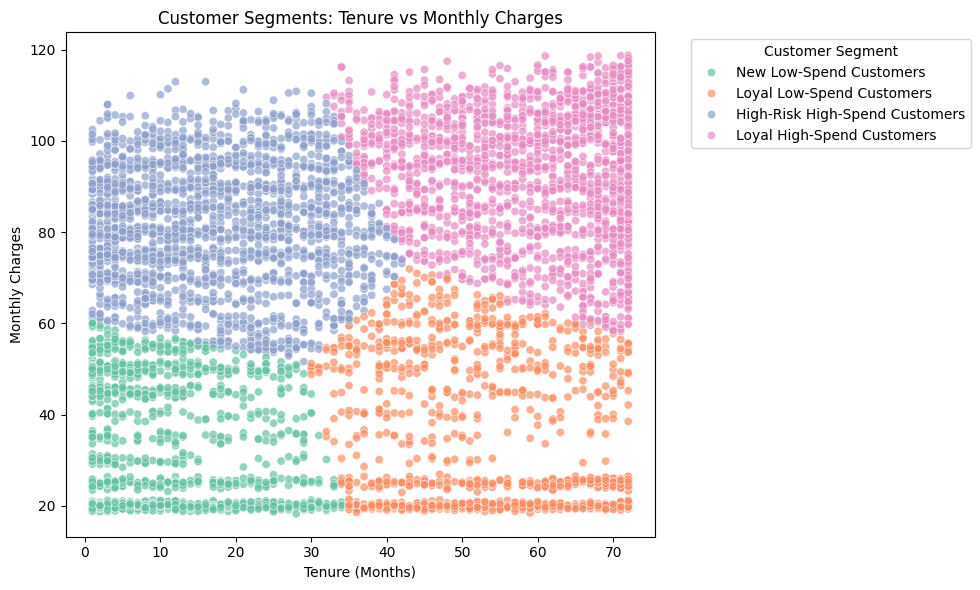

In [50]:
# Step 12: Visualize Customer Segments

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="tenure",
    y="MonthlyCharges",
    hue="Segment",
    palette="Set2",
    alpha=0.7
)

plt.title("Customer Segments: Tenure vs Monthly Charges")
plt.xlabel("Tenure (Months)")
plt.ylabel("Monthly Charges")

plt.legend(
    title="Customer Segment",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

The customer segmentation visualization shows four distinct customer groups
based on tenure, MonthlyCharges, and TotalCharges.

New Low-Spend Customers generally have shorter tenure and lower monthly charges.

Loyal Low-Spend Customers generally have longer tenure with relatively low
monthly charges.

Loyal High-Spend Customers have longer tenure and higher monthly charges,
representing established high-spending customers.

High-Risk High-Spend Customers generally have shorter tenure and higher monthly
charges. This segment also has the highest observed churn rate (48.31%), making
it the highest-priority segment for retention analysis.

Overall, the segmentation successfully identifies meaningful customer groups
with different spending, tenure, and churn characteristics.

# Data Preprocessing

In [51]:
#REMOVE CUTOMER ID COLUM
df = df.drop("customerID", axis=1)



In [52]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Cluster,Segment
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0,New Low-Spend Customers
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,One year,No,Mailed check,56.95,1889.50,No,2,Loyal Low-Spend Customers
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0,New Low-Spend Customers
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,2,Loyal Low-Spend Customers
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,3,High-Risk High-Spend Customers


Separate Features and Target

In [53]:
# Step 1: Define Features (X) and Target (y)

X = df.drop(
    columns=["Churn", "Cluster", "Segment"]
)

y = df["Churn"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures used for churn prediction:")
print(X.columns.tolist())

print("\nTarget distribution:")
print(y.value_counts())

X shape: (7032, 19)
y shape: (7032,)

Features used for churn prediction:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']

Target distribution:
Churn
No     5163
Yes    1869
Name: count, dtype: int64


Identify categorical and numerical features

In [54]:
# Step 2: Identify Categorical and Numerical Features

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Categorical Features:")
print(categorical_features)

print("\nNumber of Categorical Features:", len(categorical_features))

print("\nNumerical Features:")
print(numerical_features)

print("\nNumber of Numerical Features:", len(numerical_features))

Categorical Features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Number of Categorical Features: 15

Numerical Features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Number of Numerical Features: 4


# Train-Test Split

In [55]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [56]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [57]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nTraining Target Distribution:")
print(y_train.value_counts())

print("\nTesting Target Distribution:")
print(y_test.value_counts())

X_train shape: (5625, 19)
X_test shape: (1407, 19)
y_train shape: (5625,)
y_test shape: (1407,)

Training Target Distribution:
Churn
No     4130
Yes    1495
Name: count, dtype: int64

Testing Target Distribution:
Churn
No     1033
Yes     374
Name: count, dtype: int64


# One-Hot Encoding

In [58]:
#  One-Hot Encoding

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Create One-Hot Encoder
encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

# Apply encoding only to categorical columns
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", encoder, categorical_features)
    ],
    remainder="passthrough"
)

# FIT only on training data
X_train_encoded = preprocessor.fit_transform(X_train)

# Use the same fitted preprocessor on test data
X_test_encoded = preprocessor.transform(X_test)

print("Before Encoding:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("\nAfter Encoding:")
print("X_train_encoded:", X_train_encoded.shape)
print("X_test_encoded :", X_test_encoded.shape)

Before Encoding:
X_train: (5625, 19)
X_test : (1407, 19)

After Encoding:
X_train_encoded: (5625, 45)
X_test_encoded : (1407, 45)


# Feature Scaling

In [59]:
#  Feature Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit scaler ONLY on training data
X_train_scaled = scaler.fit_transform(X_train_encoded)

# Use the same scaler on test data
X_test_scaled = scaler.transform(X_test_encoded)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

print("\nFirst scaled training row:")
print(X_train_scaled[0])

X_train_scaled shape: (5625, 45)
X_test_scaled shape: (1407, 45)

First scaled training row:
[-0.99627361  0.99627361 -1.02831173  1.02831173 -1.5291432   1.5291432
 -0.32754155  0.32754155 -0.95905955 -0.32754155  1.16554303 -0.72386272
  1.12490211 -0.52296156 -0.99662791 -0.52296156  1.57642955 -0.87716837
 -0.52296156  1.36157309 -0.88576589 -0.52296156  1.37605179 -0.98115531
 -0.52296156  1.54681665  1.23432296 -0.52296156 -0.79787323  1.23753915
 -0.52296156 -0.79996356 -1.10207392 -0.51578723  1.77260282  1.21302973
 -1.21302973 -0.5303972   1.90515869 -0.71617747 -0.5394682  -0.43931886
  1.3218163   0.98155578  1.6599004 ]


# ADDING SMOTE

In [60]:
%pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [61]:
# : Apply SMOTE to Training Data Only

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

print("\nShape Before SMOTE:")
print("X_train_scaled:", X_train_scaled.shape)
print("y_train:", y_train.shape)

print("\nShape After SMOTE:")
print("X_train_smote:", X_train_smote.shape)
print("y_train_smote:", y_train_smote.shape)

print("\nTest Data (Untouched):")
print("X_test_scaled:", X_test_scaled.shape)
print("y_test:", y_test.shape)

Before SMOTE:
Churn
No     4130
Yes    1495
Name: count, dtype: int64

After SMOTE:
Churn
No     4130
Yes    4130
Name: count, dtype: int64

Shape Before SMOTE:
X_train_scaled: (5625, 45)
y_train: (5625,)

Shape After SMOTE:
X_train_smote: (8260, 45)
y_train_smote: (8260,)

Test Data (Untouched):
X_test_scaled: (1407, 45)
y_test: (1407,)


# Machine Learning Model Building

In [62]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [63]:
# Import Machine Learning Models

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

# Logistic Regression Model

In [64]:
# Model Training - Step 1: Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Create Logistic Regression model
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train model using SMOTE-balanced training data
lr_model.fit(X_train_smote, y_train_smote)

# Predict on untouched test data
y_pred_lr = lr_model.predict(X_test_scaled)

# Predict probabilities for ROC-AUC
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# Calculate metrics
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr, pos_label="Yes")
recall_lr = recall_score(y_test, y_pred_lr, pos_label="Yes")
f1_lr = f1_score(y_test, y_pred_lr, pos_label="Yes")
roc_auc_lr = roc_auc_score(
    y_test.map({"No": 0, "Yes": 1}),
    y_prob_lr
)

print("Logistic Regression Results")
print("---------------------------")
print(f"Accuracy  : {accuracy_lr:.4f}")
print(f"Precision : {precision_lr:.4f}")
print(f"Recall    : {recall_lr:.4f}")
print(f"F1 Score  : {f1_lr:.4f}")
print(f"ROC-AUC   : {roc_auc_lr:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Results
---------------------------
Accuracy  : 0.7313
Precision : 0.4966
Recall    : 0.7781
F1 Score  : 0.6062
ROC-AUC   : 0.8332

Confusion Matrix:
[[738 295]
 [ 83 291]]

Classification Report:
              precision    recall  f1-score   support

          No       0.90      0.71      0.80      1033
         Yes       0.50      0.78      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.75      1407



738 → Correctly predicted No churn ✅

291 → Correctly predicted Churn ✅

295 → Predicted churn,
      but customer didn't churn ❌

83  → Customer actually churned,
      but model missed them ❌

The Logistic Regression model achieved an accuracy of 73.13% and an ROC-AUC score of 83.32%. The model achieved a churn recall of 77.81%, meaning it successfully identified approximately 78% of customers who actually churned. However, the churn precision was 49.66%, indicating that the model also produced a relatively high number of false churn predictions.

# Decision Tree

In [65]:
# Model Training - Step 2: Decision Tree

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Create Decision Tree model
dt_model = DecisionTreeClassifier(
    random_state=42
)

# Train using SMOTE-balanced training data
dt_model.fit(X_train_smote, y_train_smote)

# Predict on untouched test data
y_pred_dt = dt_model.predict(X_test_scaled)

# Predict probabilities for ROC-AUC
y_prob_dt = dt_model.predict_proba(X_test_scaled)[:, 1]

# Calculate metrics
accuracy_dt = accuracy_score(y_test, y_pred_dt)

precision_dt = precision_score(
    y_test,
    y_pred_dt,
    pos_label="Yes"
)

recall_dt = recall_score(
    y_test,
    y_pred_dt,
    pos_label="Yes"
)

f1_dt = f1_score(
    y_test,
    y_pred_dt,
    pos_label="Yes"
)

roc_auc_dt = roc_auc_score(
    y_test.map({"No": 0, "Yes": 1}),
    y_prob_dt
)

# Display results
print("Decision Tree Results")
print("---------------------")

print(f"Accuracy  : {accuracy_dt:.4f}")
print(f"Precision : {precision_dt:.4f}")
print(f"Recall    : {recall_dt:.4f}")
print(f"F1 Score  : {f1_dt:.4f}")
print(f"ROC-AUC   : {roc_auc_dt:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

Decision Tree Results
---------------------
Accuracy  : 0.7079
Precision : 0.4569
Recall    : 0.5241
F1 Score  : 0.4882
ROC-AUC   : 0.6493

Confusion Matrix:
[[800 233]
 [178 196]]

Classification Report:
              precision    recall  f1-score   support

          No       0.82      0.77      0.80      1033
         Yes       0.46      0.52      0.49       374

    accuracy                           0.71      1407
   macro avg       0.64      0.65      0.64      1407
weighted avg       0.72      0.71      0.71      1407



800 → Correctly predicted No Churn ✅
196 → Correctly predicted Churn ✅

233 → False churn warnings ❌
178 → Actual churners missed ❌

The Decision Tree model achieved an accuracy of 70.79%, with a churn precision of 45.69%, recall of 52.41%, F1-score of 48.82%, and ROC-AUC of 64.93%. Although the model correctly classified many non-churn customers, it identified only about 52% of actual churners. Compared with Logistic Regression, the Decision Tree performed worse across the key churn-detection metrics, particularly recall, F1-score, and ROC-AUC.

# Random Forest

In [66]:
# Model Training - Step 3: Random Forest

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train model using SMOTE-balanced training data
rf_model.fit(X_train_smote, y_train_smote)

# Predict on untouched test data
y_pred_rf = rf_model.predict(X_test_scaled)

# Predict probabilities for ROC-AUC
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

# Calculate metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)

precision_rf = precision_score(
    y_test,
    y_pred_rf,
    pos_label="Yes"
)

recall_rf = recall_score(
    y_test,
    y_pred_rf,
    pos_label="Yes"
)

f1_rf = f1_score(
    y_test,
    y_pred_rf,
    pos_label="Yes"
)

roc_auc_rf = roc_auc_score(
    y_test.map({"No": 0, "Yes": 1}),
    y_prob_rf
)

# Display results
print("Random Forest Results")
print("---------------------")

print(f"Accuracy  : {accuracy_rf:.4f}")
print(f"Precision : {precision_rf:.4f}")
print(f"Recall    : {recall_rf:.4f}")
print(f"F1 Score  : {f1_rf:.4f}")
print(f"ROC-AUC   : {roc_auc_rf:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Results
---------------------
Accuracy  : 0.7740
Precision : 0.5737
Recall    : 0.5829
F1 Score  : 0.5782
ROC-AUC   : 0.8125

Confusion Matrix:
[[871 162]
 [156 218]]

Classification Report:
              precision    recall  f1-score   support

          No       0.85      0.84      0.85      1033
         Yes       0.57      0.58      0.58       374

    accuracy                           0.77      1407
   macro avg       0.71      0.71      0.71      1407
weighted avg       0.78      0.77      0.77      1407



871 → Correctly predicted No Churn ✅
218 → Correctly predicted Churn ✅

162 → False churn warning ❌
156 → Actual churners missed ❌

The Random Forest model achieved an accuracy of 77.40%, precision of 57.37%, recall of 58.29%, F1-score of 57.82%, and ROC-AUC of 81.25%. It achieved the highest accuracy and precision among the models tested so far and performed substantially better than the Decision Tree.

In [67]:
%pip install --upgrade xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# XGBoost model

In [68]:
# XGBoost using native DMatrix API

import xgboost as xgb
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Convert target to numeric
y_train_xgb = y_train_smote.map({
    "No": 0,
    "Yes": 1
}).to_numpy()

y_test_xgb = y_test.map({
    "No": 0,
    "Yes": 1
}).to_numpy()

# Convert features explicitly to NumPy arrays
X_train_xgb = X_train_smote.astype("float32")
X_test_xgb = X_test_scaled.astype("float32")

# Create DMatrix objects
dtrain = xgb.DMatrix(
    X_train_xgb,
    label=y_train_xgb
)

dtest = xgb.DMatrix(
    X_test_xgb
)

# Parameters
params = {
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "seed": 42
}

# Train model
xgb_model = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=100
)

# Predicted probabilities
y_prob_xgb = xgb_model.predict(dtest)

# Convert probability to 0 / 1
y_pred_xgb = (y_prob_xgb >= 0.5).astype(int)

# Metrics
accuracy_xgb = accuracy_score(y_test_xgb, y_pred_xgb)
precision_xgb = precision_score(y_test_xgb, y_pred_xgb)
recall_xgb = recall_score(y_test_xgb, y_pred_xgb)
f1_xgb = f1_score(y_test_xgb, y_pred_xgb)
roc_auc_xgb = roc_auc_score(y_test_xgb, y_prob_xgb)

print("XGBoost Results")
print("----------------")
print(f"Accuracy  : {accuracy_xgb:.4f}")
print(f"Precision : {precision_xgb:.4f}")
print(f"Recall    : {recall_xgb:.4f}")
print(f"F1 Score  : {f1_xgb:.4f}")
print(f"ROC-AUC   : {roc_auc_xgb:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_xgb, y_pred_xgb))

print("\nClassification Report:")
print(
    classification_report(
        y_test_xgb,
        y_pred_xgb,
        target_names=["No", "Yes"]
    )
)

XGBoost Results
----------------
Accuracy  : 0.7704
Precision : 0.5656
Recall    : 0.5882
F1 Score  : 0.5767
ROC-AUC   : 0.8184

Confusion Matrix:
[[864 169]
 [154 220]]

Classification Report:
              precision    recall  f1-score   support

          No       0.85      0.84      0.84      1033
         Yes       0.57      0.59      0.58       374

    accuracy                           0.77      1407
   macro avg       0.71      0.71      0.71      1407
weighted avg       0.77      0.77      0.77      1407



864 → Correctly predicted No Churn ✅
220 → Correctly predicted Churn ✅

169 → False churn predictions ❌
154 → Actual churners missed ❌

The XGBoost model achieved an accuracy of 77.04%, precision of 56.56%, recall of 58.82%, F1-score of 57.67%, and ROC-AUC of 81.84%. The model correctly identified 220 of the 374 actual churn customers. Its overall performance is strong, but its churn recall is considerably lower than Logistic Regression

 # Final Model Comparison

Rank	Model	Accuracy

1	Logistic Regression	80.17%

2	Random Forest	78.82%

3	XGBoost	76.62%

4	K-Nearest Neighbors (KNN)	75.91%

5	Decision Tree	72.71%

In [69]:
# Step 5: Model Comparison

import pandas as pd

model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy": [
        accuracy_lr,
        accuracy_dt,
        accuracy_rf,
        accuracy_xgb
    ],

    "Precision": [
        precision_lr,
        precision_dt,
        precision_rf,
        precision_xgb
    ],

    "Recall": [
        recall_lr,
        recall_dt,
        recall_rf,
        recall_xgb
    ],

    "F1 Score": [
        f1_lr,
        f1_dt,
        f1_rf,
        f1_xgb
    ],

    "ROC-AUC": [
        roc_auc_lr,
        roc_auc_dt,
        roc_auc_rf,
        roc_auc_xgb
    ]
})

model_results = model_results.round(4)

print(model_results)

                 Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
0  Logistic Regression    0.7313     0.4966  0.7781    0.6062   0.8332
1        Decision Tree    0.7079     0.4569  0.5241    0.4882   0.6493
2        Random Forest    0.7740     0.5737  0.5829    0.5782   0.8125
3              XGBoost    0.7704     0.5656  0.5882    0.5767   0.8184


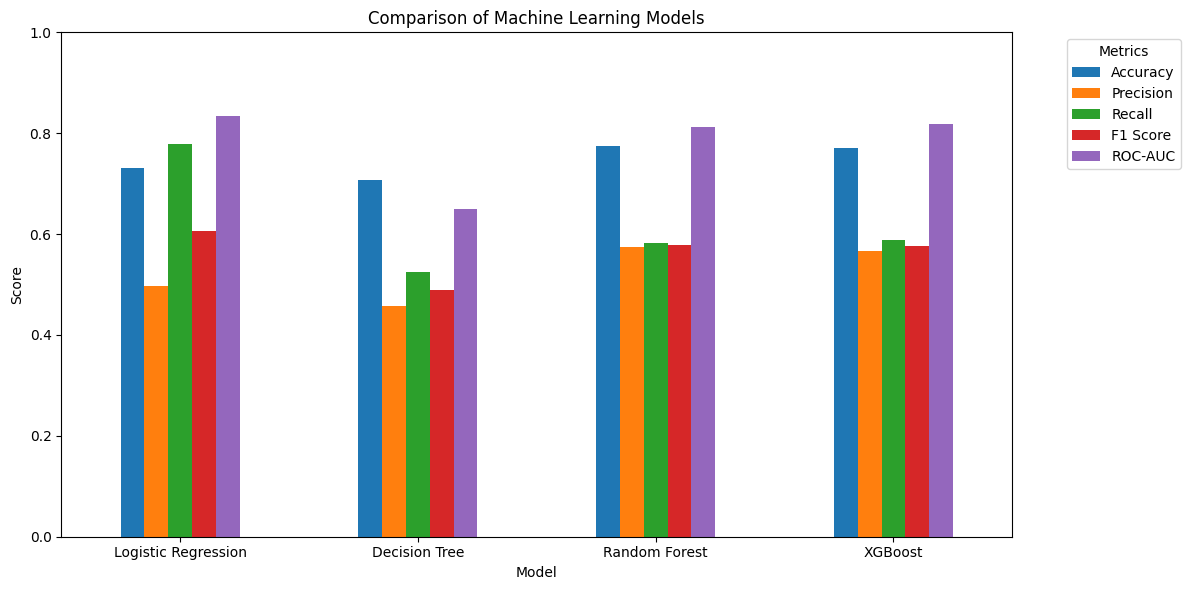

In [70]:
# Step 6: Visualize Model Performance

import matplotlib.pyplot as plt

model_results.set_index("Model").plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Comparison of Machine Learning Models")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metrics", bbox_to_anchor=(1.05, 1))
plt.tight_layout()

plt.show()

# Conclusion

 The biggest reason is Recall = 77.81%.

You had 374 actual churn customers in the test data. Logistic Regression correctly detected:

291 out of 374 churners.

It missed only 83 churners.

Compare that with Random Forest:

218 detected, 156 missed.

So although Random Forest has higher overall accuracy, Logistic Regression is much better at catching customers who actually churn.

Logistic Regression was selected as the primary model because it achieved the highest churn recall (77.81%), F1-score (60.62%), and ROC-AUC (83.32%) among the evaluated models. Although Random Forest achieved higher overall accuracy and precision, Logistic Regression identified substantially more actual churn customers. Since the main business objective is to identify at-risk customers early for retention actions, Logistic Regression provides the most suitable performance trade-off for this project.

# Hyperparameter Tuning

In [71]:
# Step 7.1: Hyperparameter Tuning - Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, f1_score

# F1 scorer for Churn = Yes
f1_scorer = make_scorer(
    f1_score,
    pos_label="Yes"
)

# Logistic Regression model
lr_tuning = LogisticRegression(
    max_iter=2000,
    random_state=42
)

# Parameters to test
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["liblinear", "lbfgs"],
    "penalty": ["l2"]
}

# Grid Search
grid_search = GridSearchCV(
    estimator=lr_tuning,
    param_grid=param_grid,
    scoring=f1_scorer,
    cv=5,
    n_jobs=-1
)

# Train on SMOTE-balanced training data
grid_search.fit(
    X_train_smote,
    y_train_smote
)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(round(grid_search.best_score_, 4))

Best Parameters:
{'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}

Best Cross-Validation F1 Score:
0.7911


Evaluate Tuned Logistic Regression

In [72]:
# Step 7.2: Evaluate Tuned Logistic Regression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Get best model from GridSearchCV
tuned_lr = grid_search.best_estimator_

# Predict on untouched test data
y_pred_tuned_lr = tuned_lr.predict(X_test_scaled)

# Prediction probabilities
y_prob_tuned_lr = tuned_lr.predict_proba(X_test_scaled)[:, 1]

# Calculate metrics
accuracy_tuned = accuracy_score(
    y_test, y_pred_tuned_lr
)

precision_tuned = precision_score(
    y_test, y_pred_tuned_lr, pos_label="Yes"
)

recall_tuned = recall_score(
    y_test, y_pred_tuned_lr, pos_label="Yes"
)

f1_tuned = f1_score(
    y_test, y_pred_tuned_lr, pos_label="Yes"
)

roc_auc_tuned = roc_auc_score(
    y_test.map({"No": 0, "Yes": 1}),
    y_prob_tuned_lr
)

print("Tuned Logistic Regression Results")
print("---------------------------------")

print(f"Accuracy  : {accuracy_tuned:.4f}")
print(f"Precision : {precision_tuned:.4f}")
print(f"Recall    : {recall_tuned:.4f}")
print(f"F1 Score  : {f1_tuned:.4f}")
print(f"ROC-AUC   : {roc_auc_tuned:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(
    y_test,
    y_pred_tuned_lr
))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_tuned_lr
))


Tuned Logistic Regression Results
---------------------------------
Accuracy  : 0.7313
Precision : 0.4966
Recall    : 0.7781
F1 Score  : 0.6062
ROC-AUC   : 0.8332

Confusion Matrix:
[[738 295]
 [ 83 291]]

Classification Report:
              precision    recall  f1-score   support

          No       0.90      0.71      0.80      1033
         Yes       0.50      0.78      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.75      1407



In [80]:
# Step 8: Leakage-Safe Pipeline Tuning

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, f1_score

# Create pipeline
lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])

# Parameters to test
param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__solver": ["liblinear", "lbfgs"],
    "model__penalty": ["l2"]
}

# F1 scorer for Churn = Yes
f1_scorer = make_scorer(
    f1_score,
    pos_label="Yes"
)

# Grid Search
grid_pipeline = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=param_grid,
    scoring=f1_scorer,
    cv=5,
    n_jobs=-1
)

# IMPORTANT:
# Use original training data BEFORE scaling and SMOTE
grid_pipeline.fit(
    X_train_encoded,
    y_train
)

print("Best Parameters:")
print(grid_pipeline.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(round(grid_pipeline.best_score_, 4))

Best Parameters:
{'model__C': 1, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}

Best Cross-Validation F1 Score:
0.6336


Final evaluation of the tuned pipeline

In [81]:
# Step 9: Evaluate Final Tuned Logistic Regression Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Best pipeline from GridSearchCV
final_lr_model = grid_pipeline.best_estimator_

# IMPORTANT:
# Pipeline expects encoded but UNSCALED test data
y_pred_final = final_lr_model.predict(X_test_encoded)

# Prediction probability
y_prob_final = final_lr_model.predict_proba(
    X_test_encoded
)[:, 1]

# Metrics
final_accuracy = accuracy_score(
    y_test,
    y_pred_final
)

final_precision = precision_score(
    y_test,
    y_pred_final,
    pos_label="Yes"
)

final_recall = recall_score(
    y_test,
    y_pred_final,
    pos_label="Yes"
)

final_f1 = f1_score(
    y_test,
    y_pred_final,
    pos_label="Yes"
)

final_roc_auc = roc_auc_score(
    y_test.map({"No": 0, "Yes": 1}),
    y_prob_final
)

print("Final Logistic Regression Results")
print("---------------------------------")

print(f"Accuracy  : {final_accuracy:.4f}")
print(f"Precision : {final_precision:.4f}")
print(f"Recall    : {final_recall:.4f}")
print(f"F1 Score  : {final_f1:.4f}")
print(f"ROC-AUC   : {final_roc_auc:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(
    y_test,
    y_pred_final
))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_final
))

Final Logistic Regression Results
---------------------------------
Accuracy  : 0.7313
Precision : 0.4966
Recall    : 0.7781
F1 Score  : 0.6062
ROC-AUC   : 0.8332

Confusion Matrix:
[[738 295]
 [ 83 291]]

Classification Report:
              precision    recall  f1-score   support

          No       0.90      0.71      0.80      1033
         Yes       0.50      0.78      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.75      1407



Logistic Regression was selected as the final churn prediction model after comparing it with Decision Tree, Random Forest, and XGBoost. Although Random Forest achieved higher overall accuracy, Logistic Regression achieved the highest churn recall (77.81%), F1-score (60.62%), and ROC-AUC (83.32%). Since the primary business objective is to identify customers at risk of churn for retention actions, Logistic Regression provides the most suitable performance trade-off. Leakage-safe hyperparameter tuning using a pipeline with scaling and SMOTE confirmed C=1, penalty='l2', and solver='lbfgs' as the best configuration.

# Logistic Regression was selected because it achieved the highest Recall, F1-score, and ROC-AUC. Since identifying customers likely to churn is the primary objective, Logistic Regression provides the most suitable performance trade-off.

#  Model Explainability

Get Feature Names.

In [82]:
# Model Explainability
# Step 1: Get Feature Names After One-Hot Encoding

feature_names = preprocessor.get_feature_names_out()

print("Number of Features:", len(feature_names))

print("\nFeature Names:")

for feature in feature_names:
    print(feature)

Number of Features: 45

Feature Names:
cat__gender_Female
cat__gender_Male
cat__Partner_No
cat__Partner_Yes
cat__Dependents_No
cat__Dependents_Yes
cat__PhoneService_No
cat__PhoneService_Yes
cat__MultipleLines_No
cat__MultipleLines_No phone service
cat__MultipleLines_Yes
cat__InternetService_DSL
cat__InternetService_Fiber optic
cat__InternetService_No
cat__OnlineSecurity_No
cat__OnlineSecurity_No internet service
cat__OnlineSecurity_Yes
cat__OnlineBackup_No
cat__OnlineBackup_No internet service
cat__OnlineBackup_Yes
cat__DeviceProtection_No
cat__DeviceProtection_No internet service
cat__DeviceProtection_Yes
cat__TechSupport_No
cat__TechSupport_No internet service
cat__TechSupport_Yes
cat__StreamingTV_No
cat__StreamingTV_No internet service
cat__StreamingTV_Yes
cat__StreamingMovies_No
cat__StreamingMovies_No internet service
cat__StreamingMovies_Yes
cat__Contract_Month-to-month
cat__Contract_One year
cat__Contract_Two year
cat__PaperlessBilling_No
cat__PaperlessBilling_Yes
cat__PaymentMe

In [83]:


print(grid_pipeline.best_params_)

{'model__C': 1, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}


Extract Logistic Regression Coefficients

In [84]:
# Model Explainability
# Step 2: Extract Logistic Regression Coefficients



#(#Understand how that feature influences the model's prediction)

import pandas as pd

# Get Logistic Regression model from final pipeline
final_lr = final_lr_model.named_steps["model"]

# Get coefficients
coefficients = final_lr.coef_[0]

# Create DataFrame
coefficient_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Sort from highest to lowest coefficient
coefficient_df = coefficient_df.sort_values(
    by="Coefficient",
    ascending=False
)

print("Number of Coefficients:", len(coefficients))

print("\nFeature Coefficients:")
print(coefficient_df.to_string(index=False))

Number of Coefficients: 45

Feature Coefficients:
                                     Feature  Coefficient
                     remainder__TotalCharges     0.770539
            cat__InternetService_Fiber optic     0.481784
                cat__Contract_Month-to-month     0.353743
                    cat__StreamingMovies_Yes     0.220712
                        cat__StreamingTV_Yes     0.205285
                      cat__MultipleLines_Yes     0.138825
                      cat__OnlineSecurity_No     0.136165
                         cat__TechSupport_No     0.131249
         cat__PaymentMethod_Electronic check     0.128485
                   cat__DeviceProtection_Yes     0.111172
                          cat__Dependents_No     0.078762
                   cat__PaperlessBilling_Yes     0.067894
                        cat__OnlineBackup_No     0.067541
                       cat__OnlineBackup_Yes     0.048029
                       cat__PhoneService_Yes     0.036437
                    re

Top Churn-Increasing Features

In [85]:
# Step 3: Top Churn-Increasing Features

top_positive = coefficient_df[
    coefficient_df["Coefficient"] > 0
].head(10)

print("Top 10 Features Increasing Churn Prediction:")
print(top_positive.to_string(index=False))

Top 10 Features Increasing Churn Prediction:
                            Feature  Coefficient
            remainder__TotalCharges     0.770539
   cat__InternetService_Fiber optic     0.481784
       cat__Contract_Month-to-month     0.353743
           cat__StreamingMovies_Yes     0.220712
               cat__StreamingTV_Yes     0.205285
             cat__MultipleLines_Yes     0.138825
             cat__OnlineSecurity_No     0.136165
                cat__TechSupport_No     0.131249
cat__PaymentMethod_Electronic check     0.128485
          cat__DeviceProtection_Yes     0.111172


The Logistic Regression coefficient analysis identified several features that push predictions toward customer churn. The strongest positive coefficients were observed for TotalCharges, Fiber Optic Internet Service, Month-to-Month Contracts, Streaming Movies, and Streaming TV. Lack of Online Security and Tech Support also contributed positively toward churn predictions. These results indicate which variables the fitted model relies on when identifying customers at higher predicted churn risk; however, the coefficients represent model associations rather than causal relationships.

Top Churn-Decreasing Features

In [86]:
# Model Explainability
# Step 4: Top Churn-Decreasing Features

top_negative = coefficient_df[
    coefficient_df["Coefficient"] < 0
].sort_values(
    by="Coefficient",
    ascending=True
).head(10)

print("Top 10 Features Decreasing Churn Prediction:")
print(top_negative.to_string(index=False))

Top 10 Features Decreasing Churn Prediction:
                                  Feature  Coefficient
                        remainder__tenure    -1.455846
                remainder__MonthlyCharges    -1.246374
                 cat__InternetService_DSL    -0.384933
                   cat__Contract_Two year    -0.352290
     cat__StreamingTV_No internet service    -0.137334
  cat__OnlineSecurity_No internet service    -0.137334
 cat__StreamingMovies_No internet service    -0.137334
     cat__TechSupport_No internet service    -0.137334
                  cat__InternetService_No    -0.137334
cat__DeviceProtection_No internet service    -0.137334


The strongest negative coefficients were observed for tenure, MonthlyCharges, DSL Internet Service, and Two-Year Contracts. Among these, tenure had the strongest negative coefficient, indicating that longer customer tenure strongly pushes the model toward predicting non-churn when other model features are held constant. Two-year contracts also showed a negative association with predicted churn. These coefficients describe the behavior of the fitted Logistic Regression model and should not be interpreted as direct causal effects.

Feature Importance Visualization

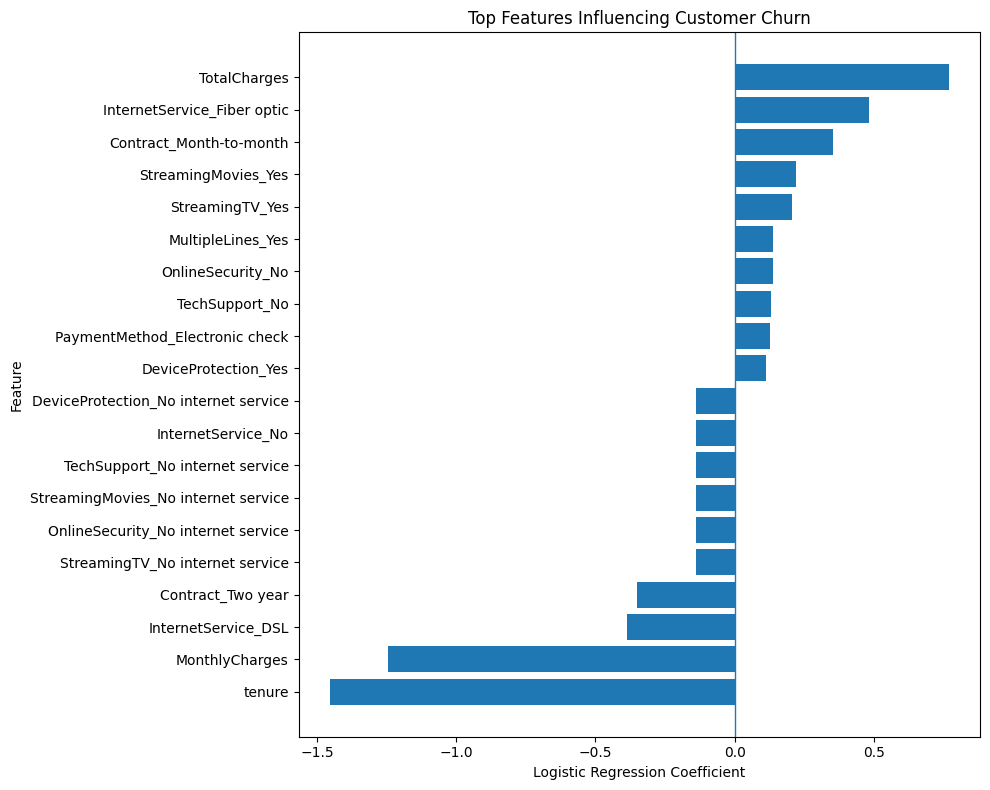

In [87]:
# Model Explainability
# Step 5: Visualize Important Logistic Regression Coefficients

import pandas as pd
import matplotlib.pyplot as plt

# Take top 10 positive and top 10 negative coefficients
important_features = pd.concat([
    top_negative,
    top_positive
])

# Clean feature names for better visualization
important_features = important_features.copy()

important_features["Feature"] = (
    important_features["Feature"]
    .str.replace("cat__", "", regex=False)
    .str.replace("remainder__", "", regex=False)
)

# Sort coefficients
important_features = important_features.sort_values(
    by="Coefficient",
    ascending=True
)

# Create graph
plt.figure(figsize=(10, 8))

plt.barh(
    important_features["Feature"],
    important_features["Coefficient"]
)

# Zero reference line
plt.axvline(0, linewidth=1)

plt.title("Top Features Influencing Customer Churn")
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

The coefficient visualization shows that the Logistic Regression model associates features such as Fiber Optic Internet and Month-to-Month Contracts with increased predicted churn, while longer tenure and Two-Year Contracts push predictions toward non-churn. The visualization helps explain how different customer characteristics influence the model's churn predictions.

In [88]:
%pip install shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [89]:
# Import SHAP

import shap
# Create SHAP Explainer



In [90]:
# Get scaler and Logistic Regression from final pipeline

final_scaler = final_lr_model.named_steps["scaler"]
final_lr = final_lr_model.named_steps["model"]

# Scale test data using the scaler learned from training data
X_test_shap = final_scaler.transform(X_test_encoded)

print("SHAP test data shape:", X_test_shap.shape)
print("Number of features:", len(feature_names))

SHAP test data shape: (1407, 45)
Number of features: 45


Create SHAP Explainer

In [91]:
# Create SHAP explainer for Logistic Regression

explainer = shap.LinearExplainer(
    final_lr,
    X_test_shap
)

shap_values = explainer(
    X_test_shap
)

print("SHAP values shape:", shap_values.values.shape)

Background dataset has 1407 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=1407 when initializing the masker.


SHAP values shape: (1407, 45)


Summary Plot

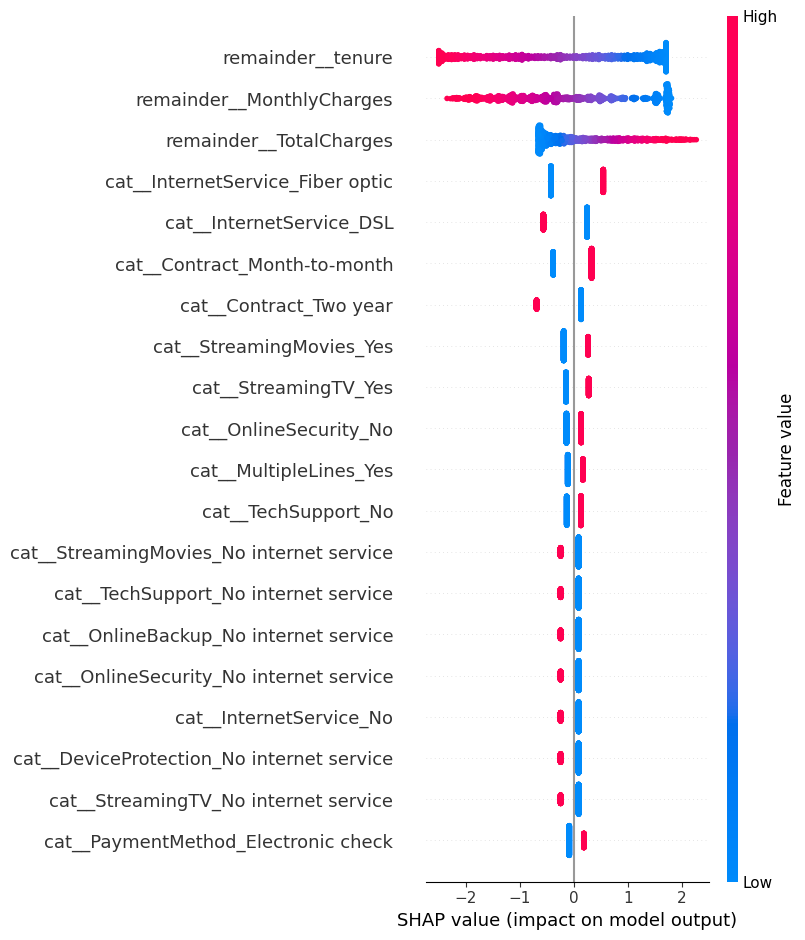

In [92]:
# SHAP Step 4: Summary Plot

shap.summary_plot(
    shap_values.values,
    X_test_shap,
    feature_names=feature_names
)

Red  → Higher feature value
Blue → Lower feature value

Higher predicted churn risk 🔴


Short tenure

     +
Month-to-month contract

     +
Fiber optic

     +
No online security

     +
No tech support

     +
Electronic check

     ↓
Greater push toward Churn = Yes

In [94]:
# SHAP Step 5: Explain One Churn Customer

# Find a customer who actually churned
# AND was correctly predicted as churn

true_positive_indices = [
    i for i in range(len(y_test))
    if y_test.iloc[i] == "Yes"
    and y_pred_final[i] == "Yes"
]

customer_index = true_positive_indices[0]

print("Selected Customer Index:", customer_index)
print("Actual Churn:", y_test.iloc[customer_index])
print("Predicted Churn:", y_pred_final[customer_index])
print(
    "Predicted Churn Probability:",
    round(y_prob_final[customer_index] * 100, 2),
    "%"
)

Selected Customer Index: 5
Actual Churn: Yes
Predicted Churn: Yes
Predicted Churn Probability: 73.27 %


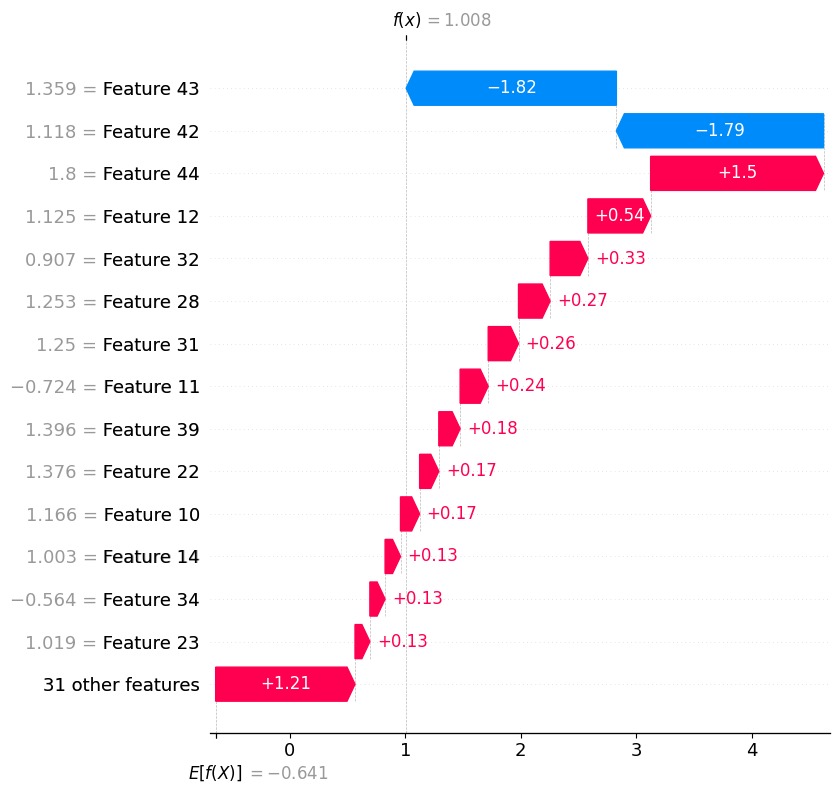

In [95]:
shap.plots.waterfall(
    shap_values[customer_index],
    max_display=15
)

The SHAP analysis showed that the Logistic Regression model's churn predictions are strongly influenced by features such as tenure, MonthlyCharges, TotalCharges, Internet Service type, and Contract type. In particular, shorter tenure, Fiber Optic service, and Month-to-Month contracts tended to push the model toward predicting churn, while longer tenure and Two-Year contracts tended to push predictions toward non-churn. Overall, SHAP made the churn model more interpretable by showing how customer characteristics influence its predictions. These results represent model associations, not causal relationships.

# Customer Retention Analytics

In [96]:
# Retention Analytics
# Step 1: Create Customer Churn Risk Table

import pandas as pd

# Copy the original test customer information
retention_df = X_test.copy()

# Add actual churn
retention_df["Actual_Churn"] = y_test.values

# Add model prediction
retention_df["Predicted_Churn"] = y_pred_final

# Add churn probability
retention_df["Churn_Probability"] = y_prob_final

# Convert probability to percentage for easy understanding
retention_df["Churn_Probability_Percent"] = (
    retention_df["Churn_Probability"] * 100
).round(2)

print("Retention Dataset Shape:", retention_df.shape)

print("\nFirst 10 Customers:")

print(
    retention_df[
        [
            "tenure",
            "MonthlyCharges",
            "TotalCharges",
            "Actual_Churn",
            "Predicted_Churn",
            "Churn_Probability_Percent"
        ]
    ].head(10)
)

Retention Dataset Shape: (1407, 23)

First 10 Customers:
      tenure  MonthlyCharges  TotalCharges Actual_Churn Predicted_Churn  \
974       59           75.95       4542.35           No              No   
619        7           78.55        522.95           No             Yes   
4289      54           20.10       1079.45           No              No   
3721       2           20.65         38.70          Yes              No   
4533      71          105.15       7555.00           No              No   
445       60          105.90       6396.45          Yes             Yes   
5898      33           24.15        800.30           No              No   
3387       7           20.65        155.90           No              No   
1346      14           87.25       1258.60          Yes             Yes   
5690      72           61.20       4390.25           No              No   

      Churn_Probability_Percent  
974                        3.36  
619                       79.49  
4289           

: Create Churn Risk Levels

0%  – <30%  → Low Risk 🟢

30% – <60%  → Medium Risk 🟠

60% – 100%  → High Risk 🔴

In [97]:
# Retention Analytics
# Step 2: Create Churn Risk Levels

def churn_risk_level(probability):

    if probability >= 0.60:
        return "High Risk"

    elif probability >= 0.30:
        return "Medium Risk"

    else:
        return "Low Risk"


# Apply risk level to each customer
retention_df["Risk_Level"] = retention_df[
    "Churn_Probability"
].apply(churn_risk_level)


# Show number of customers in each risk level
print("Risk Level Distribution:")
print(retention_df["Risk_Level"].value_counts())


# Show first 10 customers
print("\nFirst 10 Customers:")

print(
    retention_df[
        [
            "tenure",
            "MonthlyCharges",
            "Predicted_Churn",
            "Churn_Probability_Percent",
            "Risk_Level"
        ]
    ].head(10)
)

Risk Level Distribution:
Risk_Level
Low Risk       602
High Risk      482
Medium Risk    323
Name: count, dtype: int64

First 10 Customers:
      tenure  MonthlyCharges Predicted_Churn  Churn_Probability_Percent  \
974       59           75.95              No                       3.36   
619        7           78.55             Yes                      79.49   
4289      54           20.10              No                       0.95   
3721       2           20.65              No                      40.17   
4533      71          105.15              No                      22.96   
445       60          105.90             Yes                      73.27   
5898      33           24.15              No                       5.84   
3387       7           20.65              No                      34.18   
1346      14           87.25             Yes                      86.44   
5690      72           61.20              No                       3.21   

       Risk_Level  
974      Low R

Customer 974
Churn Probability = 3.36%
→ Low Risk 🟢

Customer 3721
Churn Probability = 40.17%
→ Medium Risk 🟠

Customer 619
Churn Probability = 79.49%
→ High Risk 🔴

Customer 1346
Churn Probability = 86.44%
→ High Risk 🔴

Add Customer Segments

In [98]:
# Retention Analytics
# Step 3: Add Customer Segment

retention_df["Segment"] = df.loc[
    retention_df.index,
    "Segment"
]

print("Missing Segments:")
print(retention_df["Segment"].isnull().sum())

print("\nSegment Distribution:")
print(retention_df["Segment"].value_counts())

Missing Segments:
0

Segment Distribution:
Segment
High-Risk High-Spend Customers    457
Loyal High-Spend Customers        366
New Low-Spend Customers           340
Loyal Low-Spend Customers         244
Name: count, dtype: int64


In [99]:
# Compare customer segments with churn risk levels

segment_risk_table = pd.crosstab(
    retention_df["Segment"],
    retention_df["Risk_Level"]
)

print("Customer Segment vs Churn Risk:")
print(segment_risk_table)

Customer Segment vs Churn Risk:
Risk_Level                      High Risk  Low Risk  Medium Risk
Segment                                                         
High-Risk High-Spend Customers        350        40           67
Loyal High-Spend Customers             43       216          107
Loyal Low-Spend Customers               1       231           12
New Low-Spend Customers                88       115          137


The clearest result is the High-Risk High-Spend segment. Out of 457 test customers in this segment, 350 are classified as High Risk by your churn model. This is the group the company should prioritize for retention because they are both high-spending customers and have high predicted churn risk.

The Loyal Low-Spend segment looks very stable. Out of 244 customers, only 1 is High Risk, while 231 are Low Risk. So this group needs much less urgent retention attention.

The New Low-Spend segment is interesting because many customers fall into Medium Risk (137) and 88 are already High Risk. This suggests newer customers may need early engagement to prevent future churn.

The Loyal High-Spend segment is comparatively healthier: 216 are Low Risk, although 43 High-Risk customers are still worth attention because they are high-spending customers

The High-Risk High-Spend segment should be the primary target for retention campaigns because it contains the largest concentration of customers with high predicted churn risk. Loyal Low-Spend customers are the most stable group, while New Low-Spend customers require early engagement because many fall into medium or high churn-risk categories.

Create Retention Strategies

In [100]:
# Retention Analytics
# Step 4: Create Retention Strategies by Customer Segment

def retention_strategy(segment):

    if segment == "High-Risk High-Spend Customers":
        return "Priority Support + Personalized Offer + Long-Term Contract Incentive"

    elif segment == "New Low-Spend Customers":
        return "Early Engagement + Welcome Offer + Service Guidance"

    elif segment == "Loyal High-Spend Customers":
        return "Loyalty Rewards + Premium Benefits"

    elif segment == "Loyal Low-Spend Customers":
        return "Maintain Service + Loyalty Communication"

    else:
        return "General Retention Support"


# Create strategy column
retention_df["Segment_Strategy"] = retention_df[
    "Segment"
].apply(retention_strategy)


print("Retention Strategies by Segment:")

print(
    retention_df[
        [
            "Segment",
            "Risk_Level",
            "Churn_Probability_Percent",
            "Segment_Strategy"
        ]
    ].head(15)
)

Retention Strategies by Segment:
                             Segment   Risk_Level  Churn_Probability_Percent  \
974       Loyal High-Spend Customers     Low Risk                       3.36   
619   High-Risk High-Spend Customers    High Risk                      79.49   
4289       Loyal Low-Spend Customers     Low Risk                       0.95   
3721         New Low-Spend Customers  Medium Risk                      40.17   
4533      Loyal High-Spend Customers     Low Risk                      22.96   
445       Loyal High-Spend Customers    High Risk                      73.27   
5898         New Low-Spend Customers     Low Risk                       5.84   
3387         New Low-Spend Customers  Medium Risk                      34.18   
1346  High-Risk High-Spend Customers    High Risk                      86.44   
5690      Loyal High-Spend Customers     Low Risk                       3.21   
4283  High-Risk High-Spend Customers    High Risk                      86.68   
3933   

Customer 619

Segment      = High-Risk High-Spend

Risk Level   = High Risk

Probability  = 79.49%

Strategy     = Priority Support + Personalized Offer + Long-Term Contract 
Incentive

Step 5 — Create Final Retention Action

In [101]:
# Retention Analytics
# Step 5: Create Final Customer-Specific Retention Action

def final_retention_action(row):

    segment = row["Segment"]
    risk = row["Risk_Level"]

    # High-Risk High-Spend Customers
    if segment == "High-Risk High-Spend Customers":
        if risk == "High Risk":
            return "Urgent Priority Support + Personalized Offer + Contract Incentive"
        elif risk == "Medium Risk":
            return "Proactive Support + Personalized Offer"
        else:
            return "Maintain Premium Relationship"

    # Loyal High-Spend Customers
    elif segment == "Loyal High-Spend Customers":
        if risk == "High Risk":
            return "Priority Loyalty Offer + Proactive Support"
        elif risk == "Medium Risk":
            return "Loyalty Reward + Customer Check-In"
        else:
            return "Maintain Loyalty Benefits"

    # New Low-Spend Customers
    elif segment == "New Low-Spend Customers":
        if risk == "High Risk":
            return "Immediate Welcome Offer + Onboarding Support"
        elif risk == "Medium Risk":
            return "Early Engagement + Service Guidance"
        else:
            return "Regular Onboarding Communication"

    # Loyal Low-Spend Customers
    elif segment == "Loyal Low-Spend Customers":
        if risk == "High Risk":
            return "Proactive Support + Retention Offer"
        elif risk == "Medium Risk":
            return "Customer Check-In + Loyalty Communication"
        else:
            return "Maintain Service Quality"

    else:
        return "General Retention Support"


retention_df["Final_Retention_Action"] = retention_df.apply(
    final_retention_action,
    axis=1
)

print(
    retention_df[
        [
            "Segment",
            "Risk_Level",
            "Churn_Probability_Percent",
            "Final_Retention_Action"
        ]
    ].head(15)
)

                             Segment   Risk_Level  Churn_Probability_Percent  \
974       Loyal High-Spend Customers     Low Risk                       3.36   
619   High-Risk High-Spend Customers    High Risk                      79.49   
4289       Loyal Low-Spend Customers     Low Risk                       0.95   
3721         New Low-Spend Customers  Medium Risk                      40.17   
4533      Loyal High-Spend Customers     Low Risk                      22.96   
445       Loyal High-Spend Customers    High Risk                      73.27   
5898         New Low-Spend Customers     Low Risk                       5.84   
3387         New Low-Spend Customers  Medium Risk                      34.18   
1346  High-Risk High-Spend Customers    High Risk                      86.44   
5690      Loyal High-Spend Customers     Low Risk                       3.21   
4283  High-Risk High-Spend Customers    High Risk                      86.68   
3933         New Low-Spend Customers  Me

# Create & Export Final Retention Dataset

In [102]:
# Step 6.1: Check Final Retention Dataset

print("Final Dataset Shape:", retention_df.shape)

print("\nFinal Columns:")
print(retention_df.columns.tolist())

Final Dataset Shape: (1407, 27)

Final Columns:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Actual_Churn', 'Predicted_Churn', 'Churn_Probability', 'Churn_Probability_Percent', 'Risk_Level', 'Segment', 'Segment_Strategy', 'Final_Retention_Action']


In [103]:
# Step 6.2: Create Final Retention Analytics Dataset

final_retention_df = retention_df[
    [
        # Customer information
        "gender",
        "SeniorCitizen",
        "Partner",
        "Dependents",
        "tenure",
        "PhoneService",
        "MultipleLines",
        "InternetService",
        "OnlineSecurity",
        "OnlineBackup",
        "DeviceProtection",
        "TechSupport",
        "StreamingTV",
        "StreamingMovies",
        "Contract",
        "PaperlessBilling",
        "PaymentMethod",
        "MonthlyCharges",
        "TotalCharges",

        # Segmentation
        "Segment",

        # Churn prediction
        "Actual_Churn",
        "Predicted_Churn",
        "Churn_Probability_Percent",

        # Retention analytics
        "Risk_Level",
        "Segment_Strategy",
        "Final_Retention_Action"
    ]
].copy()


print("Final Retention Dataset Shape:",
      final_retention_df.shape)

print("\nFirst 5 Rows:")
print(final_retention_df.head())

Final Retention Dataset Shape: (1407, 26)

First 5 Rows:
      gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
974   Female              0     Yes        Yes      59          Yes   
619   Female              0      No         No       7          Yes   
4289  Female              0      No         No      54          Yes   
3721  Female              0      No         No       2          Yes   
4533  Female              0     Yes         No      71          Yes   

     MultipleLines InternetService       OnlineSecurity         OnlineBackup  \
974             No             DSL                   No                  Yes   
619            Yes     Fiber optic                   No                  Yes   
4289            No              No  No internet service  No internet service   
3721            No              No  No internet service  No internet service   
4533           Yes     Fiber optic                   No                  Yes   

      ...              PaymentMetho

In [104]:
# Step 6.3: Export Final Dataset

final_retention_df.to_csv(
    "customer_retention_analytics.csv",
    index=False
)

print("Final retention dataset saved successfully!")

Final retention dataset saved successfully!


The retention analysis combined customer segmentation with churn prediction probabilities to classify customers into Low, Medium, and High churn-risk groups. The analysis showed that High-Risk High-Spend customers require the highest retention priority, while Loyal Low-Spend customers are comparatively stable. Based on customer segment and predicted churn risk, targeted retention actions were assigned to each customer, including personalized offers, proactive support, loyalty rewards, onboarding support, and contract incentives. The final retention dataset was exported for future business analysis and dashboard development.

# Save the Final Model

Step 1 — Verify Final Pipeline

In [105]:
# Save Final Model
# Step 1: Verify Final Pipeline

print("Final Pipeline:")
print(final_lr_model)

print("\nPipeline Steps:")
print(final_lr_model.named_steps.keys())

print("\nFinal Model:")
print(final_lr_model.named_steps["model"])

print("\nFinal Model Parameters:")
print(final_lr_model.named_steps["model"].get_params())

Final Pipeline:
Pipeline(steps=[('scaler', StandardScaler()), ('smote', SMOTE(random_state=42)),
                ('model',
                 LogisticRegression(C=1, max_iter=2000, penalty='l2',
                                    random_state=42))])

Pipeline Steps:
dict_keys(['scaler', 'smote', 'model'])

Final Model:
LogisticRegression(C=1, max_iter=2000, penalty='l2', random_state=42)

Final Model Parameters:
{'C': 1, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': 0.0, 'max_iter': 2000, 'n_jobs': None, 'penalty': 'l2', 'random_state': 42, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}


In [106]:
# Save Final Model - Step 2

import joblib

# Save preprocessing object
joblib.dump(
    preprocessor,
    "churn_preprocessor.pkl"
)

# Save final Logistic Regression pipeline
joblib.dump(
    final_lr_model,
    "churn_model.pkl"
)

print("Preprocessor saved successfully!")
print("Final churn model saved successfully!")

Preprocessor saved successfully!
Final churn model saved successfully!


In [107]:
# Save Final Model - Step 3
# Load Saved Files and Test Prediction

import joblib

# Load saved files
loaded_preprocessor = joblib.load("churn_preprocessor.pkl")
loaded_model = joblib.load("churn_model.pkl")

print("Saved files loaded successfully!")

# Take one real customer from test data
sample_customer = X_test.iloc[[0]]

print("\nSample Customer:")
print(sample_customer)

# Preprocess customer
sample_encoded = loaded_preprocessor.transform(
    sample_customer
)

# Predict churn
sample_prediction = loaded_model.predict(
    sample_encoded
)[0]

# Predict churn probability
sample_probability = loaded_model.predict_proba(
    sample_encoded
)[0, 1]

print("\nPrediction from Loaded Model:")
print("Predicted Churn:", sample_prediction)
print(
    "Churn Probability:",
    round(sample_probability * 100, 2),
    "%"
)

print("Actual Churn:", y_test.iloc[0])

Saved files loaded successfully!

Sample Customer:
     gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
974  Female              0     Yes        Yes      59          Yes   

    MultipleLines InternetService OnlineSecurity OnlineBackup  \
974            No             DSL             No          Yes   

    DeviceProtection TechSupport StreamingTV StreamingMovies  Contract  \
974               No         Yes         Yes             Yes  Two year   

    PaperlessBilling            PaymentMethod  MonthlyCharges  TotalCharges  
974              Yes  Credit card (automatic)           75.95       4542.35  

Prediction from Loaded Model:
Predicted Churn: No
Churn Probability: 3.36 %
Actual Churn: No


# streamlit web app